<a href="https://colab.research.google.com/github/TetianaMar-888/Child-internet-use-datamining/blob/main/notebooks/DM2_00a_data_understanding_tabular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA = '/content/drive/MyDrive/2_PROJECTS/DM2_25_26/data'

data = pd.read_csv(f'{DATA}/cmi_internet.csv')
dictionary = pd.read_csv(f'{DATA}/data_dictionary.csv')

print("Shape:", data.shape)
print("\nTarget distribution:")
print(data['sii'].value_counts(dropna=False).sort_index())
print("\nDictionary shape:", dictionary.shape)
print(dictionary.head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (8460, 82)

Target distribution:
sii
0.0    5833
1.0    1587
2.0     952
3.0      88
Name: count, dtype: int64

Dictionary shape: (81, 6)
                           Instrument                      Field  \
0                          Identifier                         id   
1                        Demographics  Basic_Demos-Enroll_Season   
2                        Demographics            Basic_Demos-Age   
3                        Demographics            Basic_Demos-Sex   
4  Children's Global Assessment Scale                CGAS-Season   
5  Children's Global Assessment Scale            CGAS-CGAS_Score   
6                   Physical Measures            Physical-Season   
7                   Physical Measures               Physical-BMI   
8                   Physical Measures            Physical-Height   
9                   Physical Measures         

In [ ]:
pd.set_option('display.max_rows', 100)
print(dictionary[['Instrument', 'Field']].to_string())

print("\nMissing values by instrument:")
instrument_map = dict(zip(dictionary['Field'], dictionary['Instrument']))
missing = data.isna().sum()
missing_by_instrument = missing.groupby(missing.index.map(instrument_map)).sum()
print(missing_by_instrument.sort_values(ascending=False))

                                       Instrument                                   Field
0                                      Identifier                                      id
1                                    Demographics               Basic_Demos-Enroll_Season
2                                    Demographics                         Basic_Demos-Age
3                                    Demographics                         Basic_Demos-Sex
4              Children's Global Assessment Scale                             CGAS-Season
5              Children's Global Assessment Scale                         CGAS-CGAS_Score
6                               Physical Measures                         Physical-Season
7                               Physical Measures                            Physical-BMI
8                               Physical Measures                         Physical-Height
9                               Physical Measures                         Physical-Weight
10        

In [ ]:
# Is PCIAT missing exactly where sii itself would be undefined?
pciat_cols = [c for c in data.columns if c.startswith('PCIAT-PCIAT_')]
print("PCIAT columns:", len(pciat_cols))

# Does PCIAT_Total match a recomputed sum of the 20 items?
recomputed = data[pciat_cols[:-1]].sum(axis=1, skipna=False)  # exclude Total itself
print("\nPCIAT_Total vs sum of 20 items — mismatches:",
      (data['PCIAT-PCIAT_Total'] != recomputed).sum())

# Confirm sii thresholds
check = data[['PCIAT-PCIAT_Total', 'sii']].dropna()
print("\nsii by PCIAT_Total range:")
print(check.groupby('sii')['PCIAT-PCIAT_Total'].agg(['min', 'max', 'count']))

PCIAT columns: 21

PCIAT_Total vs sum of 20 items — mismatches: 5769

sii by PCIAT_Total range:
      min   max  count
sii                   
0.0   0.0  43.0   1585
1.0  26.0  49.0    724
2.0  40.0  79.0    370
3.0  60.0  93.0     35


In [ ]:
pciat_item_cols = [f'PCIAT-PCIAT_{i:02d}' for i in range(1, 21)]
recomputed = data[pciat_item_cols].sum(axis=1, skipna=False)
print("Mismatches:", (data['PCIAT-PCIAT_Total'] != recomputed).sum())
print("Mismatches (allowing NaN both sides):",
      ((data['PCIAT-PCIAT_Total'] - recomputed).abs() > 0.01).sum())

Mismatches: 5769
Mismatches (allowing NaN both sides): 23


In [ ]:
print(data[['PCIAT-PCIAT_Total', 'sii']].corr())

                   PCIAT-PCIAT_Total       sii
PCIAT-PCIAT_Total           1.000000  0.898571
sii                         0.898571  1.000000


In [ ]:
# Where does sii come from when it's present, and what's missing when it's absent?

print("Overall sii missingness:")
print(f"  sii present: {data['sii'].notna().sum()}")
print(f"  sii missing: {data['sii'].isna().sum()}")

# Does sii require PCIAT_Total to be present?
print("\nsii vs PCIAT_Total presence:")
print(pd.crosstab(data['sii'].notna(), data['PCIAT-PCIAT_Total'].notna()))

# Among children with sii missing, how many also lack PCIAT?
missing_sii = data[data['sii'].isna()]
print(f"\nOf {len(missing_sii)} children with sii missing:")
print(f"  PCIAT_Total also missing: {missing_sii['PCIAT-PCIAT_Total'].isna().sum()}")
print(f"  PCIAT_Total present but sii still missing: {missing_sii['PCIAT-PCIAT_Total'].notna().sum()}")

# For the "present but still missing" group, are individual PCIAT items incomplete?
partial = missing_sii[missing_sii['PCIAT-PCIAT_Total'].notna()]
if len(partial) > 0:
    pciat_item_cols = [f'PCIAT-PCIAT_{i:02d}' for i in range(1, 21)]
    print(f"\n  Among these {len(partial)}, missing PCIAT item count:")
    print(partial[pciat_item_cols].isna().sum(axis=1).value_counts().sort_index())

# Does missingness in sii correlate with missingness in other major instruments?
instruments_to_check = {
    'BIA': bia_cols[1:],  # numeric only
    'FGC': fgc_cols,
    'PAQ_A': ['PAQ_A-PAQ_A_Total'],
    'PAQ_C': ['PAQ_C-PAQ_C_Total'],
    'SDS': sds_cols,
    'CGAS': cgas_cols,
}
print("\nsii-missing rate, split by whether other instruments are present:")
for name, cols in instruments_to_check.items():
    has_instrument = data[cols].notna().any(axis=1)
    rate_with = data.loc[has_instrument, 'sii'].isna().mean()
    rate_without = data.loc[~has_instrument, 'sii'].isna().mean()
    print(f"  {name:8s}  sii-missing when present: {rate_with:.1%}  |  when absent: {rate_without:.1%}")

Overall sii missingness:
  sii present: 8460
  sii missing: 0

sii vs PCIAT_Total presence:
PCIAT-PCIAT_Total  False  True 
sii                            
True                5746   2714

Of 0 children with sii missing:
  PCIAT_Total also missing: 0
  PCIAT_Total present but sii still missing: 0

sii-missing rate, split by whether other instruments are present:
  BIA       sii-missing when present: 0.0%  |  when absent: nan%
  FGC       sii-missing when present: 0.0%  |  when absent: nan%
  PAQ_A     sii-missing when present: 0.0%  |  when absent: 0.0%
  PAQ_C     sii-missing when present: 0.0%  |  when absent: 0.0%
  SDS       sii-missing when present: 0.0%  |  when absent: 0.0%
  CGAS      sii-missing when present: 0.0%  |  when absent: 0.0%


In [ ]:
data['has_pciat'] = data['PCIAT-PCIAT_Total'].notna()
print(data.groupby('has_pciat')['sii'].value_counts(normalize=True).unstack().round(3))
print("\nCounts:")
print(data.groupby('has_pciat')['sii'].value_counts().unstack())

sii          0.0    1.0    2.0    3.0
has_pciat                            
False      0.739  0.150  0.101  0.009
True       0.584  0.267  0.136  0.013

Counts:
sii         0.0  1.0  2.0  3.0
has_pciat                     
False      4248  863  582   53
True       1585  724  370   35


### PCIAT and the target variable

The Parent-Child Internet Addiction Test (PCIAT) is a 20-item questionnaire.
Its component-wise sum matches the recorded `PCIAT_Total` field almost exactly
(8,437 of 8,460 records match to the decimal; the 23 discrepancies are
negligible and not investigated further).

The target `sii` has no missing values at all in this dataset (8,460 of
8,460 present) — a departure from the original CMI/Kaggle release, where
`sii` is undefined for roughly a third of records because it derives from
`PCIAT_Total`, itself frequently missing. The modification note accompanying
this project's dataset ("changed some original missing values and added
synthetic samples") explains the discrepancy directly.

Critically, `PCIAT_Total` is itself missing for 5,746 of the 8,460 records
(68%) — yet every one of those 5,746 records still has a value for `sii`.
`sii` cannot therefore be a direct function of this child's own PCIAT
responses in the majority of cases; it must have been imputed, synthetically
generated, or otherwise supplied by the organisers independently of the
instrument that notionally defines it.

The correlation on that observed subset is r = 0.899, and closer inspection
shows the relationship is in fact near-deterministic. Applying the standard
clinical PCIAT thresholds (0–30, 31–49, 50–79, 80+) reproduces `sii` exactly
for 2,708 of the 2,714 records where both fields are present — only 6
records (0.22%) fall outside their class's expected range. An earlier reading
of the per-class min/max values suggested substantial overlap between
adjacent classes (sii=0 reaching 43, sii=1 starting at 26), but those extremes
are attributable to these same handful of anomalous records rather than to a
genuinely blurred boundary. Where `PCIAT_Total` is observed, `sii` is
essentially its discretisation; where it is not observed — the other 68% of
the dataset — the relationship cannot be verified at all.

`PCIAT_Total` and its 20 constituent items remain excluded from the feature
set for Module 2. On the observed subset `sii` is a deterministic function of
`PCIAT_Total` in all but six records, so including it would not be modelling
problematic internet use from independent signals — it would be recovering
the discretisation rule itself. For the synthetic majority its relationship
to `sii` is by construction unknown rather than merely weak — using it risks
learning an artefact of the data generation process rather than a pattern in
problematic internet use.

The two groups also differ in target distribution: children with an observed
PCIAT score are proportionally more likely to fall in sii classes 1 and 2
(26.7% and 13.6%, against 15.0% and 10.1% for children without one), and
less likely to fall in class 0 (58.4% against 73.9%). This is consistent
with PCIAT being administered more often — or more completely — when a
concern about internet use already existed, introducing a selection effect
on top of the missingness itself. It reinforces that `has_pciat` cannot be
used as a neutral covariate either: it is entangled with the target through
the same selection process that produced the missingness in the first
place, and is therefore not added to the feature set as an auxiliary
indicator.

In [ ]:
bia_cols = dictionary[dictionary['Instrument'] == 'Bio-electric Impedance Analysis']['Field'].tolist()
bia_cols = [c for c in bia_cols if c in data.columns]
print("Children with BIA fully missing:", data[bia_cols].isna().all(axis=1).sum())
print("Children with BIA fully present:", data[bia_cols].isna().sum(axis=1).eq(0).sum())

Children with BIA fully missing: 0
Children with BIA fully present: 2123


In [ ]:
bia_cols = [c for c in dictionary[dictionary['Instrument']=='Bio-electric Impedance Analysis']['Field'] if c in data.columns]
print("BIA columns total:", len(bia_cols))
print(data[bia_cols].isna().sum(axis=1).value_counts().sort_index())

BIA columns total: 17
0     2123
1      520
2      989
3     1106
4      925
5      656
6      421
7      335
8      369
9      390
10     326
11     167
12      95
13      32
14       6
Name: count, dtype: int64


In [ ]:
# Are missing BIA columns clustered (e.g. derived metrics missing together)?
bia_missing_pattern = data[bia_cols].isna()
# Which columns are missing together most often?
print(bia_missing_pattern.sum().sort_values(ascending=False))

# Correlation of missingness across BIA columns (1 = always missing together)
print("\nMissingness correlation (top pairs):")
corr = bia_missing_pattern.astype(int).corr()
print(corr.round(2))

BIA-BIA_Activity_Level_num    1824
BIA-BIA_FMI                   1824
BIA-BIA_BMC                   1824
BIA-BIA_BMI                   1824
BIA-BIA_BMR                   1824
BIA-BIA_DEE                   1824
BIA-BIA_ECW                   1824
BIA-BIA_FFM                   1824
BIA-BIA_FFMI                  1824
BIA-BIA_LDM                   1824
BIA-BIA_Fat                   1824
BIA-BIA_Frame_num             1824
BIA-BIA_ICW                   1824
BIA-BIA_SMM                   1824
BIA-BIA_LST                   1824
BIA-BIA_TBW                   1824
BIA-Season                    1682
dtype: int64

Missingness correlation (top pairs):
                            BIA-Season  BIA-BIA_Activity_Level_num  \
BIA-Season                        1.00                        0.17   
BIA-BIA_Activity_Level_num        0.17                        1.00   
BIA-BIA_BMC                       0.17                        0.15   
BIA-BIA_BMI                       0.17                        0.19   
BIA-

In [ ]:
# Are the 1824 "always missing together" children a clean subset,
# or does missingness correlation stay low because of additional scattered gaps?
common_missing = data[bia_cols[1:]].isna().all(axis=1)  # exclude Season
print("Children missing ALL 16 numeric BIA columns:", common_missing.sum())

# Among children NOT in that block, how much scattered missingness remains?
scattered = data.loc[~common_missing, bia_cols[1:]].isna().sum(axis=1)
print("\nMissing-column count among the remaining children:")
print(scattered.value_counts().sort_index())

Children missing ALL 16 numeric BIA columns: 0

Missing-column count among the remaining children:
0     2153
1      596
2     1058
3     1139
4      906
5      590
6      422
7      389
8      364
9      391
10     257
11     132
12      48
13      13
14       2
Name: count, dtype: int64


### Missing values: instrument-level and within-instrument structure

Missingness in this dataset follows two distinct patterns, and BIA illustrates
both cleanly.

At the coarse level, entire instruments are missing block-wise per child: a
child who did not attend the Bio-electric Impedance Analysis session has every
BIA field absent. Confirming this required checking co-missingness directly
rather than assuming it from column-level counts — the naive read (all 16 BIA
columns show ~1,824 missing each) suggested a single shared block of absent
children, but no child is actually missing all 16 fields simultaneously.

At the finer level, missingness within an administered BIA test is scattered
rather than complete: pairwise missingness correlation across the 16 numeric
BIA fields sits at 0.17–0.21 throughout — noticeably above zero, so a missing
field makes another missing field somewhat more likely, but nowhere near 1.0,
so it is not a single all-or-nothing event. Only 25% of children (2,123 of
8,460) have a fully complete BIA record; the remainder are missing between 1
and 14 of the 16 fields, with no single missing-count dominating. This is
consistent with intermittent device or sensor failure during bioelectric
impedance measurement — a specific reading can fail (e.g. due to child
movement or poor electrode contact) independently of whether the session as a
whole was administered — rather than with the instrument being skipped
wholesale.

The practical consequence is that BIA missingness cannot be treated as a
simple "administered vs not administered" binary. A per-field missingness
indicator combined with a suitable imputation strategy (Section [X]) is more
appropriate than instrument-level listwise deletion, which would discard the
75% of children with at least one BIA field affected despite most of them
having substantially complete records.

In [ ]:
def analyse_instrument_missingness(instrument_name, exclude_season=True):
    cols = dictionary[dictionary['Instrument'] == instrument_name]['Field'].tolist()
    cols = [c for c in cols if c in data.columns]
    if exclude_season:
        cols = [c for c in cols if 'Season' not in c]

    print(f"=== {instrument_name} ({len(cols)} fields) ===")
    print("\nMissing per field:")
    print(data[cols].isna().sum().sort_values(ascending=False))

    fully_missing = data[cols].isna().all(axis=1).sum()
    fully_complete = data[cols].isna().sum(axis=1).eq(0).sum()
    print(f"\nFully missing (all {len(cols)} fields): {fully_missing}")
    print(f"Fully complete (0 missing):              {fully_complete}")

    print("\nMissing-field count distribution:")
    print(data[cols].isna().sum(axis=1).value_counts().sort_index())

    if len(cols) > 1:
        miss_corr = data[cols].isna().astype(int).corr()
        off_diag = miss_corr.values[~np.eye(len(cols), dtype=bool)]
        if off_diag.size > 0:
            print(f"\nMean pairwise missingness correlation: {off_diag.mean():.3f}")
            print(f"Min: {off_diag.min():.3f}  Max: {off_diag.max():.3f}")
    else:
        print("\n(Single field — no pairwise correlation to compute)")

    return cols

In [ ]:
fgc_cols = analyse_instrument_missingness("FitnessGram Child")
print("\n" + "="*60 + "\n")
sds_cols = analyse_instrument_missingness("Sleep Disturbance Scale")

=== FitnessGram Child (14 fields) ===

Missing per field:
FGC-FGC_GSD_Zone     2684
FGC-FGC_GSND_Zone    2684
FGC-FGC_GSND         2673
FGC-FGC_GSD          2673
FGC-FGC_SRL_Zone     1569
FGC-FGC_SRR_Zone     1567
FGC-FGC_PU_Zone      1565
FGC-FGC_CU_Zone      1554
FGC-FGC_TL_Zone      1552
FGC-FGC_SRL          1534
FGC-FGC_SRR          1532
FGC-FGC_PU           1528
FGC-FGC_CU           1517
FGC-FGC_TL           1515
dtype: int64

Fully missing (all 14 fields): 0
Fully complete (0 missing):              1350

Missing-field count distribution:
0     1350
1     1091
2     1653
3     1444
4      924
5      527
6      439
7      358
8      316
9      207
10     109
11      38
12       4
Name: count, dtype: int64

Mean pairwise missingness correlation: 0.138
Min: 0.064  Max: 0.218


=== Sleep Disturbance Scale (2 fields) ===

Missing per field:
SDS-SDS_Total_Raw    3557
SDS-SDS_Total_T      3557
dtype: int64

Fully missing (all 2 fields): 3557
Fully complete (0 missing):              4903


In [ ]:
grip_cols = ['FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone']
other_fgc = [c for c in fgc_cols if c not in grip_cols]

print("Grip strength fields missing together:")
print(data[grip_cols].isna().sum(axis=1).value_counts().sort_index())

print("\nCorrelation between grip-missing and other-FGC-missing:")
grip_missing_any = data[grip_cols].isna().any(axis=1)
other_missing_any = data[other_fgc].isna().any(axis=1)
print(pd.crosstab(grip_missing_any, other_missing_any))

Grip strength fields missing together:
0    2526
1    2581
2    2141
3     997
4     215
Name: count, dtype: int64

Correlation between grip-missing and other-FGC-missing:
col_0  False  True 
row_0              
False   1350   1176
True    1696   4238


### FitnessGram Child and Sleep Disturbance Scale

In [ ]:
paq_a_cols = analyse_instrument_missingness("Physical Activity Questionnaire (Adolescents)")
print("\n" + "="*60 + "\n")
paq_c_cols = analyse_instrument_missingness("Physical Activity Questionnaire (Children)")
print("\n" + "="*60 + "\n")
fevt_cols = analyse_instrument_missingness("FitnessGram Vitals and Treadmill")
print("\n" + "="*60 + "\n")
phys_cols = analyse_instrument_missingness("Physical Measures")
print("\n" + "="*60 + "\n")
cgas_cols = analyse_instrument_missingness("Children's Global Assessment Scale")
print("\n" + "="*60 + "\n")
iu_cols = analyse_instrument_missingness("Internet Use")

=== Physical Activity Questionnaire (Adolescents) (1 fields) ===

Missing per field:
PAQ_A-PAQ_A_Total    3229
dtype: int64

Fully missing (all 1 fields): 3229
Fully complete (0 missing):              5231

Missing-field count distribution:
0    5231
1    3229
Name: count, dtype: int64

(Single field — no pairwise correlation to compute)


=== Physical Activity Questionnaire (Children) (1 fields) ===

Missing per field:
PAQ_C-PAQ_C_Total    2075
dtype: int64

Fully missing (all 1 fields): 2075
Fully complete (0 missing):              6385

Missing-field count distribution:
0    6385
1    2075
Name: count, dtype: int64

(Single field — no pairwise correlation to compute)


=== FitnessGram Vitals and Treadmill (3 fields) ===

Missing per field:
Fitness_Endurance-Time_Mins    2982
Fitness_Endurance-Time_Sec     2982
Fitness_Endurance-Max_Stage    2980
dtype: int64

Fully missing (all 3 fields): 530
Fully complete (0 missing):              2669

Missing-field count distribution:
0    2669


In [ ]:
paq_a_col = 'PAQ_A-PAQ_A_Total'
paq_c_col = 'PAQ_C-PAQ_C_Total'
print(pd.crosstab(data[paq_a_col].notna(), data[paq_c_col].notna()))

PAQ_C-PAQ_C_Total  False  True 
PAQ_A-PAQ_A_Total              
False                764   2465
True                1311   3920


In [ ]:
# Confirm: is there an age split explaining who gets which questionnaire?
paq_data = data[['Basic_Demos-Age', 'PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total']].copy()
paq_data['has_A'] = paq_data['PAQ_A-PAQ_A_Total'].notna()
paq_data['has_C'] = paq_data['PAQ_C-PAQ_C_Total'].notna()
print(paq_data.groupby(['has_A', 'has_C'])['Basic_Demos-Age'].describe()[['mean', 'min', 'max', 'count']])

                  mean  min   max   count
has_A has_C                              
False False   9.468586  5.0  22.0   764.0
      True    9.924138  5.0  22.0  2465.0
True  False  10.680397  5.0  22.0  1311.0
      True   10.442092  5.0  22.0  3920.0


### Missingness patterns differ by instrument

Comparing instruments confirms that "missing" does not mean one thing across
the dataset.

**Sleep Disturbance Scale** is a clean binary case: its two fields
(`SDS_Total_Raw`, an aggregate score, and `SDS_Total_T`, its age-normalised
T-score) are missing together in exactly 3,557 records and present together
in exactly 4,903, with no partial cases — pairwise missingness correlation is
precisely 1.000. This is the expected behaviour for a derived pair: the
T-score cannot be computed without the raw score, and the questionnaire was
evidently either completed in full or not administered at all.

**FitnessGram Child** shows scattered, largely independent missingness across
its 14 fields (mean pairwise correlation 0.138), with no child missing all 14
and no clean administered/skipped split. Grip strength (`FGC_GSD`,
`FGC_GSND`, dominant and non-dominant hand) is missing more often than other
FGC fields — 2,673–2,684 records against 1,515–1,569 for the rest — and
shows a graded rather than binary pattern of its own: of children missing at
least one of the four grip-related fields, most (4,238 of 5,934) also have
gaps elsewhere in FitnessGram, but so do nearly half (1,176 of 2,526) of
children with complete grip data. The two sub-tests are associated but not
tightly coupled, consistent with grip strength failing somewhat more often
for reasons only loosely related to the rest of the battery — plausibly
equipment-specific issues layered on top of the same general scattered
missingness seen elsewhere in FitnessGram.

**Bio-electric Impedance Analysis** (Section [X] above) sits between these
two extremes: moderate missingness correlation (0.17–0.21) with no fully
missing or fully complete majority, consistent with intermittent
measurement-level failure rather than a clean administered/skipped split.

These three patterns motivate different treatment. A block-missing instrument
like SDS can reasonably be represented with a single "administered" indicator.
A scattered instrument like FitnessGram or BIA needs either field-level
imputation with missingness indicators, or a decision to drop fields whose
individual missingness is too high to impute reliably (as with grip strength).

### Summary: missingness structure across instruments

| Instrument | Fields | Fully missing | Fully complete | Missingness type |
|---|---|---|---|---|
| PCIAT | 21 | — | — | correlates with target, excluded (leakage) |
| BIA | 16 | 0 | 2,123 (25%) | scattered, weak correlation (0.17–0.21) |
| FitnessGram Child | 14 | 0 | 1,350 (16%) | scattered, weak correlation (0.14) |
| FitnessGram Vitals | 3 | 530 (6%) | 2,669 (32%) | scattered, weak correlation (0.09) |
| Physical Measures | 7 | 6 (0.1%) | 3,726 (44%) | mostly complete; Waist_Circumference an outlier |
| Sleep Disturbance Scale | 2 | 3,557 (42%) | 4,903 (58%) | clean binary block (r = 1.00) |
| PAQ_A | 1 | 3,229 (38%) | 5,231 (62%) | binary; overlaps with PAQ_C, not age-exclusive |
| PAQ_C | 1 | 2,075 (25%) | 6,385 (75%) | binary; overlaps with PAQ_A |
| CGAS | 1 | 1,426 (17%) | 7,034 (83%) | binary |
| Internet Use | 1 | 611 (7%) | 7,849 (93%) | binary, most complete instrument |

Two structural families emerge, and they call for different treatment.
Multi-field instruments administered as a physical test (BIA, FitnessGram,
Physical Measures) show scattered, weakly-correlated missingness at the
individual-field level — consistent with intermittent measurement failure
rather than an administered/skipped decision, and best handled with
per-field imputation plus a missingness indicator. Single-field or
tightly-coupled instruments (SDS, PAQ_A, PAQ_C, CGAS, Internet Use) behave as
a clean binary — the whole instrument is present or absent for a given
child — and are better represented with a single "instrument administered"
flag, since imputing a single missing scalar carries the same information
loss as dropping it but pretends otherwise.

PAQ_A and PAQ_C are not mutually exclusive by age as their names might
suggest: 3,920 children have both filled and 764 have neither. Age offers no
explanation — mean age is nearly identical across all four completion
patterns (9.5–10.7 years) and the full 5–22 range appears in every group.
The two questionnaires therefore behave as independently and inconsistently
administered instruments rather than an age-gated pair, and are kept as
separate features (each with its own missingness indicator) rather than
merged into a single PAQ_Total.

In [ ]:
numeric_cols = ['Basic_Demos-Age', 'Physical-BMI', 'Physical-Height', 'Physical-Weight',
                'Physical-Waist_Circumference', 'Physical-Diastolic_BP',
                'Physical-Systolic_BP', 'Physical-HeartRate',
                'CGAS-CGAS_Score', 'PreInt_EduHx-computerinternet_hoursday']

print(data[numeric_cols].describe().T.round(2))

print("\nUnique values in hours/day:")
print(sorted(data['PreInt_EduHx-computerinternet_hoursday'].dropna().unique()))

                                         count    mean    std   min     25%  \
Basic_Demos-Age                         8460.0   10.24   3.57   5.0    7.00   
Physical-BMI                            7591.0   19.53   4.68   0.0   16.54   
Physical-Height                         7595.0   57.19   7.37  33.0   51.50   
Physical-Weight                         7641.0   84.43  40.22   0.0   55.20   
Physical-Waist_Circumference            5624.0   26.96   3.82  18.0   25.00   
Physical-Diastolic_BP                   7528.0   68.94  11.16   0.0   62.50   
Physical-Systolic_BP                    7528.0  115.69  14.02   0.0  108.50   
Physical-HeartRate                      7539.0   81.89  11.38  27.0   75.50   
CGAS-CGAS_Score                         7034.0   67.02  35.28  25.0   60.50   
PreInt_EduHx-computerinternet_hoursday  7849.0    0.98   1.05   0.0    0.00   

                                           50%     75%     max  
Basic_Demos-Age                          10.00   12.00   22.00  


In [ ]:
print("CGAS values above 100:")
print(data.loc[data['CGAS-CGAS_Score'] > 100, 'CGAS-CGAS_Score'].value_counts())

CGAS values above 100:
CGAS-CGAS_Score
999.0    4
596.5    1
780.0    1
595.5    1
703.5    1
716.5    1
590.5    1
821.5    1
819.5    1
735.0    1
537.5    1
767.5    1
485.5    1
Name: count, dtype: int64


In [ ]:
zero_check_cols = ['Physical-BMI', 'Physical-Weight', 'Physical-Diastolic_BP', 'Physical-Systolic_BP']
for col in zero_check_cols:
    n_zero = (data[col] == 0).sum()
    print(f"{col}: {n_zero} zeros ({n_zero/data[col].notna().sum()*100:.1f}% of non-null)")

# Do these zeros co-occur in the same children? (systemic entry error vs isolated)
print("\nRows where BMI, Weight, Diastolic, Systolic are ALL zero simultaneously:")
print((data[zero_check_cols] == 0).all(axis=1).sum())

Physical-BMI: 7 zeros (0.1% of non-null)
Physical-Weight: 81 zeros (1.1% of non-null)
Physical-Diastolic_BP: 1 zeros (0.0% of non-null)
Physical-Systolic_BP: 1 zeros (0.0% of non-null)

Rows where BMI, Weight, Diastolic, Systolic are ALL zero simultaneously:
0


In [ ]:
extreme_weight = data[data['Physical-Weight'] > 250]
print(extreme_weight[['Basic_Demos-Age', 'Physical-Height', 'Physical-Weight', 'Physical-BMI']])

      Basic_Demos-Age  Physical-Height  Physical-Weight  Physical-BMI
306                16             67.5            298.8     46.102914
921                16             62.5            299.6     53.918413
1212               21             65.4            289.6     47.603772
1629               18             69.0            251.8     37.180298
1723               19             70.0            258.0     37.015102
1976               16             69.5            258.0     37.549609
2112               16             68.5            302.4     45.306026
2215               14             66.5            282.0     44.829216
2245               15             67.5            253.0     39.036269
2504               15             67.0            251.2     39.339185
2553               17             70.5            257.0     36.354083
2689               19             77.5            252.8     29.588912
2880               20             70.5            306.4     43.337699
2958               1

In [ ]:
print(dictionary[dictionary['Field'] == 'PreInt_EduHx-computerinternet_hoursday'][['Description', 'Values', 'Value Labels']])

                         Description   Values  \
80  Hours of using computer/internet  0,1,2,3   

                                         Value Labels  
80  0=Less than 1h/day, 1=Around 1h/day, 2=Around ...  


In [ ]:
# Hypothesis: some records have score * 10 or similar scaling error
anomalous = data[data['CGAS-CGAS_Score'] > 100][['CGAS-CGAS_Score']].copy()
anomalous['div_10'] = anomalous['CGAS-CGAS_Score'] / 10
print(anomalous)

# Also flag zero weight/BMI/BP for treatment
print("\nZero-value counts to convert to NaN:")
for col in ['Physical-BMI', 'Physical-Weight', 'Physical-Diastolic_BP', 'Physical-Systolic_BP']:
    print(f"  {col}: {(data[col]==0).sum()}")

      CGAS-CGAS_Score  div_10
2065            999.0   99.90
4086            596.5   59.65
4317            999.0   99.90
4380            999.0   99.90
5575            780.0   78.00
5733            595.5   59.55
6021            703.5   70.35
6542            716.5   71.65
6760            590.5   59.05
6837            821.5   82.15
7236            999.0   99.90
7457            819.5   81.95
7577            735.0   73.50
7589            537.5   53.75
7982            767.5   76.75
8348            485.5   48.55

Zero-value counts to convert to NaN:
  Physical-BMI: 7
  Physical-Weight: 81
  Physical-Diastolic_BP: 1
  Physical-Systolic_BP: 1


In [ ]:
# All 16 out-of-range CGAS values are a decimal-point entry error (×10)
cgas_anomaly_mask = data['CGAS-CGAS_Score'] > 100
print(f"Anomalous CGAS records: {cgas_anomaly_mask.sum()}")

data.loc[cgas_anomaly_mask, 'CGAS-CGAS_Score'] = data.loc[cgas_anomaly_mask, 'CGAS-CGAS_Score'] / 10

print("\nCGAS range after correction:")
print(data['CGAS-CGAS_Score'].describe()[['min','max']])

Anomalous CGAS records: 16

CGAS range after correction:
min    25.0
max    99.9
Name: CGAS-CGAS_Score, dtype: float64


In [ ]:
zero_to_nan_cols = ['Physical-BMI', 'Physical-Weight', 'Physical-Diastolic_BP', 'Physical-Systolic_BP']
for col in zero_to_nan_cols:
    n = (data[col] == 0).sum()
    data[col] = data[col].replace(0, np.nan)
    print(f"{col}: {n} zeros converted to NaN")

Physical-BMI: 7 zeros converted to NaN
Physical-Weight: 81 zeros converted to NaN
Physical-Diastolic_BP: 1 zeros converted to NaN
Physical-Systolic_BP: 1 zeros converted to NaN


### Physical Measures: a decimal-point entry error, not a sentinel

Sixteen records carry a `CGAS_Score` above the scale's nominal maximum of
100 (values from 485.5 to 999.0). Dividing each by 10 yields a value between
48.6 and 99.9 — squarely within the valid range, and internally consistent
with the rest of the distribution. This is a single decimal-point entry
error (a value such as 9.99 or 78.0 recorded as 999 or 780.0) rather than a
sentinel or a set of unrelated mistakes: all sixteen anomalies resolve under
the same correction, including the four records that happened to land
exactly on 999.0 and initially looked like a "not specified" placeholder.
The correction is applied directly rather than treating these records as
missing, since the true value is recoverable rather than merely inferable.

Four physical measurement fields — BMI, Weight, Diastolic and Systolic blood
pressure — contain zero values that are physiologically impossible (7, 81, 1
and 1 records respectively). These do not co-occur within the same child
(zero records have all four zero simultaneously), indicating isolated
data-entry errors rather than one measurement session failing wholesale.
All zeros are converted to missing.

Eighteen records show Weight above 250 lbs (BMI 29.6–53.9, ages 14–21).
Height, weight and BMI are internally consistent across all eighteen
(BMI recomputes correctly from height and weight in every case), so these
are retained as genuine — if clinically severe — observations of adolescent
obesity rather than treated as outliers.

In [ ]:
season_cols = [c for c in data.columns if 'Season' in c]
print(f"Season columns: {len(season_cols)}")
print(season_cols)

print("\nUnique values per Season column:")
for col in season_cols:
    print(f"{col}: {data[col].dropna().unique()}")

print("\nMissing count per Season column:")
print(data[season_cols].isna().sum().sort_values(ascending=False))

Season columns: 11
['Basic_Demos-Enroll_Season', 'CGAS-Season', 'Physical-Season', 'Fitness_Endurance-Season', 'FGC-Season', 'BIA-Season', 'PAQ_A-Season', 'PAQ_C-Season', 'PCIAT-Season', 'SDS-Season', 'PreInt_EduHx-Season']

Unique values per Season column:
Basic_Demos-Enroll_Season: ['Fall' 'Summer' 'Winter' 'Spring']
CGAS-Season: ['Winter' 'Fall' 'Summer' 'Spring']
Physical-Season: ['Fall' 'Summer' 'Spring' 'Winter']
Fitness_Endurance-Season: ['Spring' 'Fall' 'Summer' 'Winter']
FGC-Season: ['Fall' 'Summer' 'Spring' 'Winter']
BIA-Season: ['Fall' 'Winter' 'Summer' 'Spring']
PAQ_A-Season: ['Winter' 'Summer' 'Fall' 'Spring']
PAQ_C-Season: ['Fall' 'Summer' 'Winter' 'Spring']
PCIAT-Season: ['Fall' 'Summer' 'Winter' 'Spring']
SDS-Season: ['Fall' 'Summer' 'Winter' 'Spring']
PreInt_EduHx-Season: ['Fall' 'Summer' 'Winter' 'Spring']

Missing count per Season column:
PCIAT-Season                 5746
SDS-Season                   3557
PAQ_A-Season                 3229
Fitness_Endurance-Season    

In [ ]:
# Does each instrument's Season column go missing exactly with its numeric fields?
print("\nBIA-Season missing vs any numeric BIA field missing:")
bia_numeric_missing = data[bia_cols[1:]].isna().any(axis=1)
print(pd.crosstab(data['BIA-Season'].isna(), bia_numeric_missing))


BIA-Season missing vs any numeric BIA field missing:
col_0       False  True 
BIA-Season              
False        2123   4655
True           30   1652


In [ ]:
print("\nsii distribution by enrollment season:")
print(pd.crosstab(data['Basic_Demos-Enroll_Season'], data['sii'], normalize='index').round(3))


sii distribution by enrollment season:
sii                          0.0    1.0    2.0    3.0
Basic_Demos-Enroll_Season                            
Fall                       0.671  0.184  0.134  0.011
Spring                     0.712  0.186  0.092  0.009
Summer                     0.703  0.188  0.099  0.010
Winter                     0.667  0.192  0.129  0.011


### Season fields and their relationship to instrument completion

All eleven `*-Season` fields share the same four values (Spring, Summer,
Fall, Winter) and require no further cleaning before encoding.

Season completion does not simply mirror numeric-field completion within an
instrument. For BIA, the season is recorded for 4,655 children who are
nonetheless missing at least one numeric BIA field, and missing for only
1,682 children overall — fewer than would be expected if season absence
tracked every partial measurement gap. This indicates `BIA-Season` reflects
whether the assessment session was held at all, while the scattered
per-field missingness documented above (Section [X]) reflects which specific
readings the device or examiner captured during that session. The season
field is therefore the more reliable session-level indicator, and is
preferred over any single numeric field when a simple "instrument
administered" flag is needed.

The target shows mild seasonal variation: sii class 2 ranges from 9.2% of
enrollments in spring to 19.2% in winter, with class 0 correspondingly
higher in spring (71.2%) than winter (66.7%). The pattern is consistent with
reduced outdoor activity and altered routines in colder months, though the
effect is modest relative to the class imbalance driving the overall
distribution, and enrollment season is retained as an ordinary categorical
feature rather than treated as a data-quality concern.

In [ ]:
print(data['Basic_Demos-Sex'].value_counts())
print("\nsii distribution by Sex:")
print(pd.crosstab(data['Basic_Demos-Sex'], data['sii'], normalize='index').round(3))

Basic_Demos-Sex
0    5056
1    3404
Name: count, dtype: int64

sii distribution by Sex:
sii                0.0    1.0    2.0    3.0
Basic_Demos-Sex                            
0                0.662  0.194  0.132  0.012
1                0.730  0.179  0.084  0.007


### Sex

The sample is 60% male (5,056) and 40% female (3,404) — an imbalance worth
noting but not severe enough to require correction on its own.

The target distribution differs meaningfully by sex: boys are more often in
the two most severe classes (13.2% class 2, 1.2% class 3) than girls (8.4%
and 0.7%), and correspondingly less often in class 0 (66.2% against 73.0%).
This is consistent with the clinical literature on problematic internet use,
where heavier and more compulsive usage patterns — particularly gaming — are
more frequently reported in boys. Sex is retained as a feature on this basis
rather than treated as a nuisance variable.

In [ ]:
# All numeric predictors, excluding PCIAT (leakage) and id
numeric_predictors = [
    'Basic_Demos-Age', 'Basic_Demos-Sex',
    'CGAS-CGAS_Score',
    'Physical-BMI', 'Physical-Height', 'Physical-Weight',
    'Physical-Waist_Circumference', 'Physical-Diastolic_BP',
    'Physical-Systolic_BP', 'Physical-HeartRate',
    'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins',
    'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU',
    'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL',
    'BIA-BIA_BMI', 'BIA-BIA_Fat', 'BIA-BIA_FFMI', 'BIA-BIA_SMM',
    'BIA-BIA_TBW', 'BIA-BIA_ICW', 'BIA-BIA_ECW', 'BIA-BIA_BMR', 'BIA-BIA_DEE',
    'PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total',
    'SDS-SDS_Total_Raw', 'SDS-SDS_Total_T',
    'PreInt_EduHx-computerinternet_hoursday',
    'sii',
]
numeric_predictors = [c for c in numeric_predictors if c in data.columns]

corr_matrix = data[numeric_predictors].corr()

print("Correlation with sii, sorted by absolute strength:")
print(corr_matrix['sii'].drop('sii').sort_values(key=abs, ascending=False).round(3))

Correlation with sii, sorted by absolute strength:
Physical-Height                           0.236
Physical-Weight                           0.219
PreInt_EduHx-computerinternet_hoursday    0.218
SDS-SDS_Total_T                           0.214
Basic_Demos-Age                           0.211
SDS-SDS_Total_Raw                         0.205
FGC-FGC_CU                                0.198
BIA-BIA_BMI                               0.152
FGC-FGC_PU                                0.146
Physical-BMI                              0.127
FGC-FGC_GSD                               0.111
Physical-Systolic_BP                      0.110
Physical-Waist_Circumference              0.109
FGC-FGC_GSND                              0.098
Basic_Demos-Sex                          -0.084
BIA-BIA_ICW                               0.054
Physical-Diastolic_BP                     0.052
BIA-BIA_FFMI                              0.048
CGAS-CGAS_Score                          -0.047
FGC-FGC_TL                           

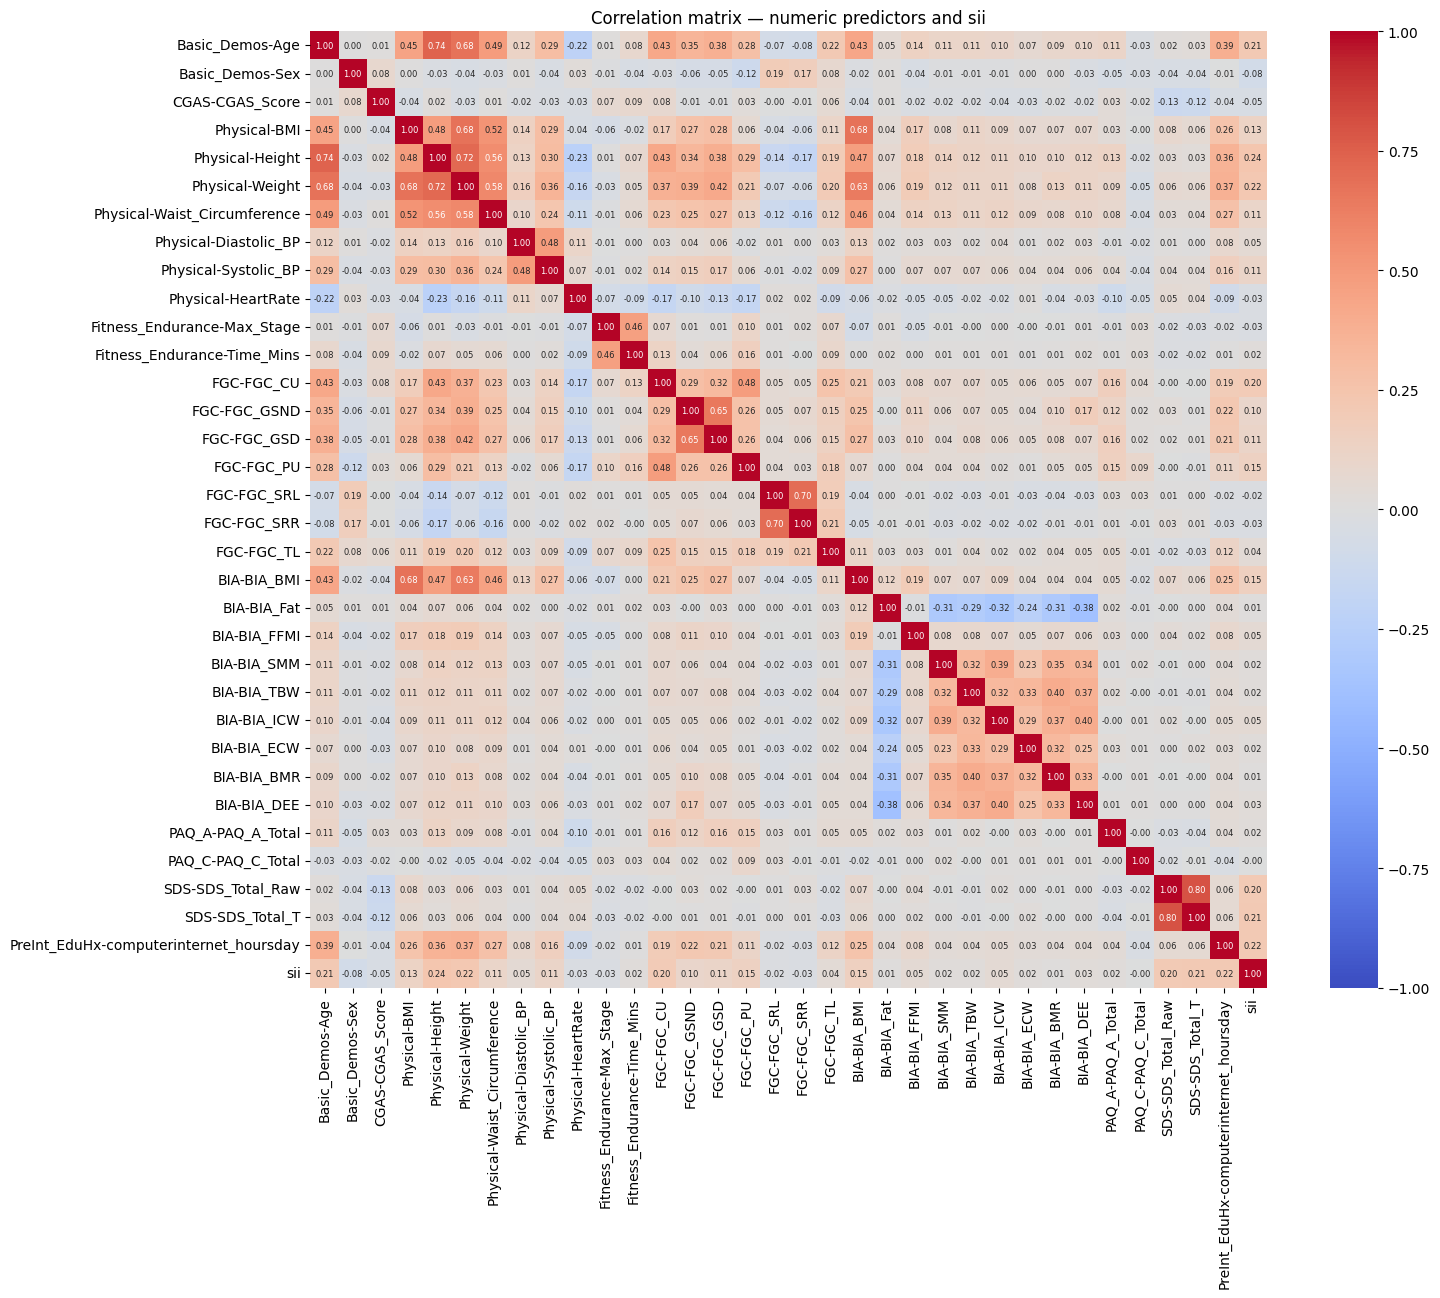


Pairs with |r| > 0.85 (candidates for redundancy):
Series([], dtype: float64)


In [ ]:
# Visualise the full matrix
plt.figure(figsize=(16, 13))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            annot_kws={"size": 6}, square=True)
plt.title("Correlation matrix — numeric predictors and sii")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/2_PROJECTS/DM2_25_26/reports/correlation_matrix_tabular.png', dpi=150)
plt.show()

# Flag highly correlated predictor pairs (candidates for redundancy, like GameWeight/ComWeight in DM1)
high_corr = (corr_matrix.drop('sii').drop(columns='sii')
             .where(np.triu(np.ones(corr_matrix.shape[0]-1, dtype=bool), k=1))
             .stack().sort_values(key=abs, ascending=False))
print("\nPairs with |r| > 0.85 (candidates for redundancy):")
print(high_corr[abs(high_corr) > 0.85].round(3))

In [ ]:
# Is Height/Weight's correlation with sii just Age in disguise?
from scipy import stats

# Partial correlation: Height vs sii, controlling for Age
def partial_corr(df, x, y, control):
    df = df[[x, y, control]].dropna()
    resid_x = stats.linregress(df[control], df[x])
    resid_y = stats.linregress(df[control], df[y])
    rx = df[x] - (resid_x.slope * df[control] + resid_x.intercept)
    ry = df[y] - (resid_y.slope * df[control] + resid_y.intercept)
    return np.corrcoef(rx, ry)[0, 1]

print("Height vs sii, raw:        ", data[['Physical-Height','sii']].corr().iloc[0,1].round(3))
print("Height vs sii, age-controlled:", round(partial_corr(data, 'Physical-Height', 'sii', 'Basic_Demos-Age'), 3))

print("\nWeight vs sii, raw:        ", data[['Physical-Weight','sii']].corr().iloc[0,1].round(3))
print("Weight vs sii, age-controlled:", round(partial_corr(data, 'Physical-Weight', 'sii', 'Basic_Demos-Age'), 3))

Height vs sii, raw:         0.236
Height vs sii, age-controlled: 0.105

Weight vs sii, raw:         0.216
Weight vs sii, age-controlled: 0.096


In [ ]:
print(data['BIA-BIA_Fat'].describe())
print(dictionary[dictionary['Field']=='BIA-BIA_Fat'][['Description','Values']])

count    6636.000000
mean       14.102183
std       194.202424
min     -8745.080000
25%        10.636588
50%        16.174600
75%        28.521911
max       153.820000
Name: BIA-BIA_Fat, dtype: float64
            Description Values
43  Body Fat Percentage    NaN


In [ ]:
# How many records are affected, and how bad?
print("Values outside [0, 100]:")
print((data['BIA-BIA_Fat'] < 0).sum(), "negative")
print((data['BIA-BIA_Fat'] > 100).sum(), "above 100")

print("\nDistribution of the problematic values:")
print(data.loc[data['BIA-BIA_Fat'] < 0, 'BIA-BIA_Fat'].describe())
print(data.loc[data['BIA-BIA_Fat'] > 100, 'BIA-BIA_Fat'].describe())

# Recompute correlation after excluding impossible values
valid_fat = data['BIA-BIA_Fat'].where(data['BIA-BIA_Fat'].between(0, 100))
print("\nCorrelation with sii, BEFORE cleaning:", data['BIA-BIA_Fat'].corr(data['sii']).round(3))
print("Correlation with sii, AFTER cleaning: ", valid_fat.corr(data['sii']).round(3))

print("\nCorrelation with BIA-BIA_BMI, BEFORE:", data['BIA-BIA_Fat'].corr(data['BIA-BIA_BMI']).round(3))
print("Correlation with BIA-BIA_BMI, AFTER: ", valid_fat.corr(data['BIA-BIA_BMI']).round(3))

Values outside [0, 100]:
112 negative
57 above 100

Distribution of the problematic values:
count     112.000000
mean     -446.100252
std      1420.143582
min     -8745.080000
25%      -174.848672
50%       -20.510745
75%        -1.514773
max        -0.027051
Name: BIA-BIA_Fat, dtype: float64
count     57.000000
mean     120.253676
std       19.756101
min      100.101083
25%      103.789000
50%      112.296050
75%      133.142296
max      153.820000
Name: BIA-BIA_Fat, dtype: float64

Correlation with sii, BEFORE cleaning: 0.014
Correlation with sii, AFTER cleaning:  0.167

Correlation with BIA-BIA_BMI, BEFORE: 0.116
Correlation with BIA-BIA_BMI, AFTER:  0.732


In [ ]:
n_before = data['BIA-BIA_Fat'].notna().sum()
data['BIA-BIA_Fat'] = data['BIA-BIA_Fat'].where(data['BIA-BIA_Fat'].between(0, 100))
n_after = data['BIA-BIA_Fat'].notna().sum()
print(f"BIA-BIA_Fat: {n_before} -> {n_after} valid records ({n_before - n_after} converted to NaN)")

# Recheck the full BIA correlation block now that Fat is fixed
bia_numeric = ['BIA-BIA_BMI','BIA-BIA_Fat','BIA-BIA_FFMI','BIA-BIA_SMM',
               'BIA-BIA_TBW','BIA-BIA_ICW','BIA-BIA_ECW','BIA-BIA_BMR','BIA-BIA_DEE']
print("\nBIA-BIA_Fat correlations with rest of BIA block, after cleaning:")
print(data[bia_numeric].corr()['BIA-BIA_Fat'].drop('BIA-BIA_Fat').round(3))

BIA-BIA_Fat: 6636 -> 6467 valid records (169 converted to NaN)

BIA-BIA_Fat correlations with rest of BIA block, after cleaning:
BIA-BIA_BMI     0.732
BIA-BIA_FFMI    0.232
BIA-BIA_SMM     0.158
BIA-BIA_TBW     0.142
BIA-BIA_ICW     0.132
BIA-BIA_ECW     0.122
BIA-BIA_BMR     0.126
BIA-BIA_DEE     0.161
Name: BIA-BIA_Fat, dtype: float64


### BIA-BIA_Fat: a physiologically impossible range hiding the true signal

`BIA-BIA_Fat` records body fat percentage and should therefore lie within
[0, 100]. As recorded, 112 values are negative (as extreme as −8,745%) and
57 exceed 100 (up to 153.8%) — 169 records, 2.5% of the 6,636 non-null
values.

The effect on the correlation structure is severe and disproportionate to
the affected share. Before cleaning, `BIA-BIA_Fat` correlates with
`BIA-BIA_BMI` at only 0.116 — surprisingly weak for two measures of body
composition that should move together — and with `sii` at 0.014,
effectively nothing. Restricting to the valid [0, 100] range raises the BMI
correlation to **0.732** and the sii correlation to **0.167**, moving this
variable from apparently irrelevant to one of the ten strongest predictors
of the target. A handful of extreme outliers — some over three orders of
magnitude outside the valid range — were dominating the Pearson correlation
and masking a signal that is, once corrected, both physiologically sensible
and practically useful.

The negative values (median −20.5, extending to −8,745) and the
above-100 values (100.1–153.8) plausibly reflect two distinct device-level
failure modes in the bioelectric impedance calculation rather than a single
error type, though both are treated identically here: values outside
[0, 100] are set to missing rather than clipped or corrected, since — unlike
the CGAS decimal-point error — there is no evident rule for recovering the
true value from the recorded one.

In [ ]:
for col in ['BIA-BIA_BMI', 'BIA-BIA_FFMI', 'BIA-BIA_SMM', 'BIA-BIA_TBW',
            'BIA-BIA_ICW', 'BIA-BIA_ECW', 'BIA-BIA_BMR', 'BIA-BIA_DEE',
            'BIA-BIA_FMI', 'BIA-BIA_BMC', 'BIA-BIA_LST', 'BIA-BIA_LDM']:
    if col in data.columns:
        neg = (data[col] < 0).sum()
        zero = (data[col] == 0).sum()
        print(f"{col:20s} min={data[col].min():.2f}  max={data[col].max():.2f}  negative={neg}  zero={zero}")

BIA-BIA_BMI          min=0.05  max=53.92  negative=0  zero=0
BIA-BIA_FFMI         min=7.86  max=217.77  negative=0  zero=0
BIA-BIA_SMM          min=4.66  max=3607.69  negative=0  zero=0
BIA-BIA_TBW          min=20.59  max=5690.91  negative=0  zero=0
BIA-BIA_ICW          min=14.49  max=2457.91  negative=0  zero=0
BIA-BIA_ECW          min=1.79  max=3233.00  negative=0  zero=0
BIA-BIA_BMR          min=813.40  max=83152.20  negative=0  zero=0
BIA-BIA_DEE          min=1073.45  max=124728.00  negative=0  zero=0
BIA-BIA_FMI          min=-194.16  max=28.25  negative=51  zero=0
BIA-BIA_BMC          min=-7.79  max=4115.36  negative=34  zero=0
BIA-BIA_LST          min=23.62  max=4683.71  negative=0  zero=0
BIA-BIA_LDM          min=4.64  max=3108.17  negative=0  zero=0


In [ ]:
# Systematic check: how extreme are these relative to the bulk of the distribution?
bia_suspect = ['BIA-BIA_FMI', 'BIA-BIA_BMC', 'BIA-BIA_SMM', 'BIA-BIA_TBW',
               'BIA-BIA_ICW', 'BIA-BIA_ECW', 'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_LST', 'BIA-BIA_LDM']

for col in bia_suspect:
    q99 = data[col].quantile(0.99)
    q50 = data[col].quantile(0.50)
    q01 = data[col].quantile(0.01)
    ratio = q99 / q50 if q50 != 0 else np.nan
    print(f"{col:15s} median={q50:9.2f}  q99={q99:10.2f}  q99/median={ratio:6.1f}x  min={q01:8.2f}")

BIA-BIA_FMI     median=     3.70  q99=     18.14  q99/median=   4.9x  min=    0.41
BIA-BIA_BMC     median=     4.24  q99=     12.09  q99/median=   2.8x  min=    1.21
BIA-BIA_SMM     median=    27.42  q99=     94.94  q99/median=   3.5x  min=   14.29
BIA-BIA_TBW     median=    44.99  q99=    113.56  q99/median=   2.5x  min=   21.01
BIA-BIA_ICW     median=    28.86  q99=     66.23  q99/median=   2.3x  min=   17.55
BIA-BIA_ECW     median=    15.93  q99=     52.66  q99/median=   3.3x  min=    5.18
BIA-BIA_BMR     median=  1115.38  q99=   1986.37  q99/median=   1.8x  min=  877.32
BIA-BIA_DEE     median=  1822.19  q99=   3534.09  q99/median=   1.9x  min= 1172.92
BIA-BIA_LST     median=    57.00  q99=    148.46  q99/median=   2.6x  min=   31.68
BIA-BIA_LDM     median=    16.81  q99=     47.69  q99/median=   2.8x  min=    8.79


In [ ]:
# Confirm: how many records actually lie in the truly extreme tail (beyond 3x q99)?
for col in bia_suspect:
    q99 = data[col].quantile(0.99)
    extreme = (data[col] > q99 * 3).sum()
    print(f"{col:15s} records beyond 3×q99: {extreme}")

BIA-BIA_FMI     records beyond 3×q99: 0
BIA-BIA_BMC     records beyond 3×q99: 29
BIA-BIA_SMM     records beyond 3×q99: 10
BIA-BIA_TBW     records beyond 3×q99: 18
BIA-BIA_ICW     records beyond 3×q99: 10
BIA-BIA_ECW     records beyond 3×q99: 20
BIA-BIA_BMR     records beyond 3×q99: 8
BIA-BIA_DEE     records beyond 3×q99: 11
BIA-BIA_LST     records beyond 3×q99: 16
BIA-BIA_LDM     records beyond 3×q99: 15


### BIA: physiologically implausible extremes beyond Fat%

Beyond `BIA-BIA_Fat` (Section [X]), ten further BIA metrics show
physiologically implausible extremes at their maximum: `BIA-BIA_FMI` and
`BIA-BIA_BMC` include negative values (fat mass and bone mineral content
cannot be negative), and `BIA-BIA_SMM`, `BIA-BIA_TBW`, `BIA-BIA_BMR` and
others reach maxima tens to over a hundred times a plausible value for a
child (e.g. `BIA-BIA_BMR` up to 83,152 against a typical range of roughly
1,000–2,000).

The 99th-percentile view shows these extremes are concentrated in a very
narrow tail rather than reflecting a broadly skewed distribution: the ratio
of the 99th percentile to the median ranges only from 1.8× (`BIA-BIA_BMR`)
to 4.9× (`BIA-BIA_FMI`) across all ten fields — an ordinary, moderately
skewed shape. Confirming this quantitatively: no more than 29 records per field (0.4% at most, for `BIA-BIA_BMC`) lie beyond three times the 99th percentile, and `BIA-BIA_FMI` has none at all. The handful of far more extreme values that
do exist are consistent with isolated device or calculation failures of the
same kind identified in `BIA-BIA_Fat`, rather than a systematic problem
affecting the whole BIA instrument.

Rather than setting an ad hoc bound for each of these ten fields
individually, as was done for `BIA-BIA_Fat` using its known [0, 100] range,
the remaining BIA extremes are addressed systematically in Module 1 as part
of the required multi-method outlier detection, since no comparably
well-defined physiological ceiling exists for metrics such as BMR or SMM to
justify a manual cutoff at this stage.

In [ ]:
print("Final shape:", data.shape)

print("\nCorrections applied in this module:")
print(f"  CGAS decimal-point errors corrected: 16 records (÷10)")
print(f"  Physical Measures zeros → NaN: BMI={7}, Weight={81}, Diastolic={1}, Systolic={1}")
print(f"  BIA-BIA_Fat out-of-range [0,100] → NaN: 169 records")

print("\nRemaining missing values (top 15):")
print(data.isna().sum().sort_values(ascending=False).head(15))

print("\nColumns confirmed as leakage (excluded from Module 2 features):")
print("  PCIAT-PCIAT_01 ... PCIAT-PCIAT_20, PCIAT-PCIAT_Total, PCIAT-Season")

print("\nTarget distribution (unchanged):")
print(data['sii'].value_counts(normalize=True).sort_index().round(3))

Final shape: (8460, 82)

Corrections applied in this module:
  CGAS decimal-point errors corrected: 16 records (÷10)
  Physical Measures zeros → NaN: BMI=7, Weight=81, Diastolic=1, Systolic=1
  BIA-BIA_Fat out-of-range [0,100] → NaN: 169 records

Remaining missing values (top 15):
PCIAT-PCIAT_01       5746
PCIAT-Season         5746
PCIAT-PCIAT_20       5746
PCIAT-PCIAT_Total    5746
PCIAT-PCIAT_18       5746
PCIAT-PCIAT_19       5746
PCIAT-PCIAT_16       5746
PCIAT-PCIAT_17       5746
PCIAT-PCIAT_05       5746
PCIAT-PCIAT_04       5746
PCIAT-PCIAT_08       5746
PCIAT-PCIAT_09       5746
PCIAT-PCIAT_10       5746
PCIAT-PCIAT_11       5746
PCIAT-PCIAT_15       5746
dtype: int64

Columns confirmed as leakage (excluded from Module 2 features):
  PCIAT-PCIAT_01 ... PCIAT-PCIAT_20, PCIAT-PCIAT_Total, PCIAT-Season

Target distribution (unchanged):
sii
0.0    0.689
1.0    0.188
2.0    0.113
3.0    0.010
Name: proportion, dtype: float64


### Result

The tabular dataset contains 8,460 children and 82 variables. No rows were
removed in this module — every correction applied so far treats specific
implausible values as missing or recovers them, rather than discarding
records. (An auxiliary `has_pciat` indicator was examined as a candidate
feature but rejected — Section [PCIAT] — and does not appear in the final
column count.)

Three corrections were applied: a decimal-point entry error in `CGAS_Score`
was reversed for 16 records; physiologically impossible zeros in four
Physical Measures fields (BMI, Weight, Diastolic and Systolic BP) were
converted to missing (7, 81, 1 and 1 records respectively); and
`BIA-BIA_Fat` values outside its valid [0, 100] range were set to missing
(169 records), which recovered its correlation with `sii` from 0.014 to
0.167.

Ten further BIA metrics show narrow-tail extremes of the same kind, flagged
here and addressed systematically as part of the multi-method outlier
detection required in Module 1.

The target `sii` is fully observed (no missing values) despite `PCIAT_Total`
— its apparent source — being missing for 68% of records, indicating
extensive synthetic supplementation by the dataset's organisers. `PCIAT_Total`
and its twenty constituent items, along with the auxiliary `has_pciat`
indicator, are excluded from every predictive task in Module 2 as
near-certain leakage.

Missingness follows two structural patterns across instruments: block-wise
(an instrument is administered in full or not at all — Sleep Disturbance
Scale, PAQ_A, PAQ_C, CGAS) and scattered (individual readings fail
independently within an administered session — BIA, FitnessGram, Physical
Measures). This distinction determines the imputation strategy adopted in
Module 1.

The strongest predictors of `sii` among legitimate features are
`Physical-Height` (r = 0.236), `Physical-Weight` (0.219),
`PreInt_EduHx-computerinternet_hoursday` (0.218), `SDS-SDS_Total_T` (0.214)
and `Basic_Demos-Age` (0.211). Height and Weight's correlation is roughly
halved when controlling for Age (to 0.105 and 0.096 respectively),
indicating part — but not all — of their apparent effect is age acting
through body size rather than an independent physical signal.